# EDA: State Transition Log

## Setup
Reset database and seed base data.

In [1]:
from pathlib import Path
import os, sys
from dotenv import load_dotenv

# Set working directory explicitly to project root
PROJECT_ROOT = Path(r"C:\Repos\codecritic").resolve()

os.chdir(PROJECT_ROOT)  # Change current directory
sys.path.insert(0, str(PROJECT_ROOT))  # Ensure imports resolve correctly

print("Working directory is now:", Path.cwd())

from app.db.connection import DB_PATH, close_connection
from sqlalchemy import create_engine
from app.db.seeders.seed_score_providers import seed_score_providers
from app.db.seeders.seed_tool_providers import seed_tool_providers
from app.db.seeders.seed_prompt_providers import seed_prompt_providers
from app.db.seeders.seed_prompts import seed_prompts
from app.db.seeders.seed_context_providers import seed_context_providers
from app.db.seeders.seed_agent_engine_providers import seed_agent_engine_providers
from app.db.seeders.seed_agent_providers import seed_agent_providers
from app.db.seeders.seed_state_providers import seed_state_providers
from app.db.seeders.seed_system_providers import seed_system_providers
from app.db.seeders.seed_controller_providers import seed_controller_providers
from app.db.seeders.seed_program_provider import seed_program_providers
from app.db.seeders.seed_session_configs import seed_session_configs
from app.db.base import Base
from sqlalchemy.orm import Session

# 🧹 Reset DB
close_connection()
engine = create_engine(f"sqlite:///{DB_PATH}")
Base.metadata.drop_all(engine)
Base.metadata.create_all(engine)

# 🌱 Seed database records
with Session(bind=engine) as session:
    seed_prompts(session)
    seed_prompt_providers(session)
    seed_tool_providers(session)
    seed_score_providers(session)
    seed_context_providers(session)
    seed_agent_engine_providers(session)
    seed_agent_providers(session)
    seed_state_providers(session)
    seed_system_providers(session)
    seed_controller_providers(session)
    seed_program_providers(session)
    seed_session_configs(session)

# Load from env/.env relative to project root
dotenv_path = Path("env/.env").resolve()
if dotenv_path.exists():
    load_dotenv(dotenv_path)
    print("✅ Loaded environment variables from env/.env")
else:
    raise FileNotFoundError(f"❌ Missing .env file at: {dotenv_path}")


Working directory is now: C:\Repos\codecritic
Seeded AgentPrompt 'generate' with ID: 1 and GUID: b49f4f0a-4273-4e47-9a88-b6a999392504
Seeded AgentPrompt 'linting_generator_agent' with ID: 2 and GUID: ccf760ef-e76d-4504-8b7a-9f70128f8280
Seeded SystemPrompt 'format' with ID: 1 and GUID: ee7591d6-3365-4b8c-9225-d118db587ed0
Seeded SystemPrompt 'linting_system' with ID: 2 and GUID: 4a7a24d4-5894-4705-902e-9a4f7def49be
Seeded prompt provider configurations successfully.
Seeded tool configurations successfully.
Seeded score providers successfully.
Seeded context provider configurations successfully.
Seeded agent engine configurations successfully.
Seeded agent provider configurations successfully.
✅ Seeded state provider configurations successfully.
✅ Seeded system provider configurations successfully.
✅ Seeded controller providers
✅ Seeded program providers
✅ Seeded session configs
✅ Loaded environment variables from env/.env


In [2]:
# 🧪 Run Program Using SessionConfig

from app.db.models import SessionConfig
from app.enums.logging_enums import PROVIDER_TYPE
from app.enums.system_enums import SYSTEM
from app.factories.program_provider_factory import ProgramProviderFactory
from sqlalchemy.orm import Session
from pathlib import Path
import json

# Fetch session config
with Session(bind=engine) as db:
    session_row = db.query(SessionConfig).filter_by(id=1).first()
    assert session_row, "❌ No session config found"

# Prepare test file
file = Path("tests/session_linked_execution.py")
file.write_text("def ping( user ):\n return f\"pong {user}\"")

# Construct input using session metadata
input_data = {
    "file_path":  str(file),
    "session_id": session_row.id,
    "system":     SYSTEM.LINTING.value
}

# Run associated program
program = ProgramProviderFactory.create(
    id=session_row.program_provider_id,
    called_by_type=PROVIDER_TYPE.SESSION,
    called_by_id=session_row.id
)
result = program.run(input_data, session_id=session_row.id)

print("✅ Final Program Result (via SessionConfig):")
print(json.dumps(result.model_dump(), indent=2))


✅ Final Program Result (via SessionConfig):
{
  "state": "end",
  "previous_state": "preprocessing_controller",
  "state_type": "end",
  "decision": "accept",
  "steps": 2,
  "max_steps": 20,
  "summary": "completed successfully",
  "output": {
    "state": "end",
    "file_path": "working_files\\final_prog_1027095631.py",
    "session_id": 1,
    "system": "linting",
    "reason": "completed successfully",
    "steps": 2,
    "retry_count": 0,
    "_last_state": "preprocessing_controller",
    "original_file": "tests\\session_linked_execution.py",
    "run_id": "9b95fd9a-66c0-41d4-affb-36de9e301572",
    "transition_metadata": {
      "original_file": "tests\\session_linked_execution.py",
      "run_id": "9b95fd9a-66c0-41d4-affb-36de9e301572",
      "agent_output": {},
      "file_path": null
    },
    "decision": "accept",
    "state_output": {
      "state": "end",
      "previous_state": "linting",
      "state_type": "end",
      "decision": "accept",
      "steps": 2,
      "max

### Load raw log entries

In [3]:
import sqlite3
import pandas as pd
import json
from app.db.connection import DB_PATH

# Connect and load transition logs
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM state_transition_log WHERE session_id='1'", conn)
conn.close()

# Sort and format
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by='timestamp').reset_index(drop=True)

# Display trace
for i, row in df.iterrows():
    print(f"\n🔹 Transition {i + 1} — ID {row['id']}")
    print(f"🕒 Timestamp: {row['timestamp']}")
    print(f"📘 From: {row['from_state']}  ➡️  To: {row['to_state']}")
    print(f"🧠 Reason: {row.get('reason') or '—'}")
    print(f"🧾 Decision: {row.get('decision') or '—'}")
    
    # Displaying extension type and ID
    called_by_type = row.get('called_by_type') or '—'
    called_by_id = row.get('called_by_id') or '—'
    print(f"👤 Triggered by: {called_by_type} (Extension ID: {called_by_id})")
    
    print(f"📍 Step #: {row.get('step') if row.get('step') is not None else '—'}")
    print(f"🏷️ Entity: {row['entity_type']} (ID {row['entity_id']})")

    if row.get("input_snapshot_id") or row.get("output_snapshot_id"):
        print(f"📥 Input Snapshot: {row.get('input_snapshot_id') or '—'}")
        print(f"📤 Output Snapshot: {row.get('output_snapshot_id') or '—'}")

    try:
        metadata = json.loads(row["transition_metadata"]) if row["transition_metadata"] else {}
        pretty_meta = json.dumps(metadata, indent=2)
        print("🧳 Metadata:")
        print(pretty_meta if pretty_meta else "  —")
    except Exception:
        print("🧳 Metadata (raw):")
        print(row["transition_metadata"] or "  —")

    print("—" * 80)




🔹 Transition 1 — ID 1
🕒 Timestamp: 2025-06-08 15:26:54.561606+00:00
📘 From: CONTROLLER.START  ➡️  To: CONTROLLER.PREPROCESSING
🧠 Reason: TRANSITION_REASON_TYPE.INITIALIZATION
🧾 Decision: STATE_DECISION_TYPE.INITIAL
👤 Triggered by: PROVIDER_TYPE.SESSION (Extension ID: 1)
📍 Step #: 1
🏷️ Entity: PROVIDER_TYPE.PROGRAM (ID 1)
🧳 Metadata:
{
  "original_file": "tests\\session_linked_execution.py",
  "run_id": "9b95fd9a-66c0-41d4-affb-36de9e301572"
}
————————————————————————————————————————————————————————————————————————————————

🔹 Transition 2 — ID 2
🕒 Timestamp: 2025-06-08 15:26:54.572613+00:00
📘 From: SYSTEM.START  ➡️  To: SYSTEM.LINTING
🧠 Reason: TRANSITION_REASON_TYPE.INITIALIZATION
🧾 Decision: STATE_DECISION_TYPE.INITIAL
👤 Triggered by: PROVIDER_TYPE.PROGRAM (Extension ID: 1)
📍 Step #: 2
🏷️ Entity: PROVIDER_TYPE.CONTROLLER (ID 1)
🧳 Metadata:
{
  "original_file": "working_files\\session_linked_execution.__prog_1026545606.py",
  "run_id": "073b07d6-b22f-4ec8-aa45-13befd6ccff9"
}
————————

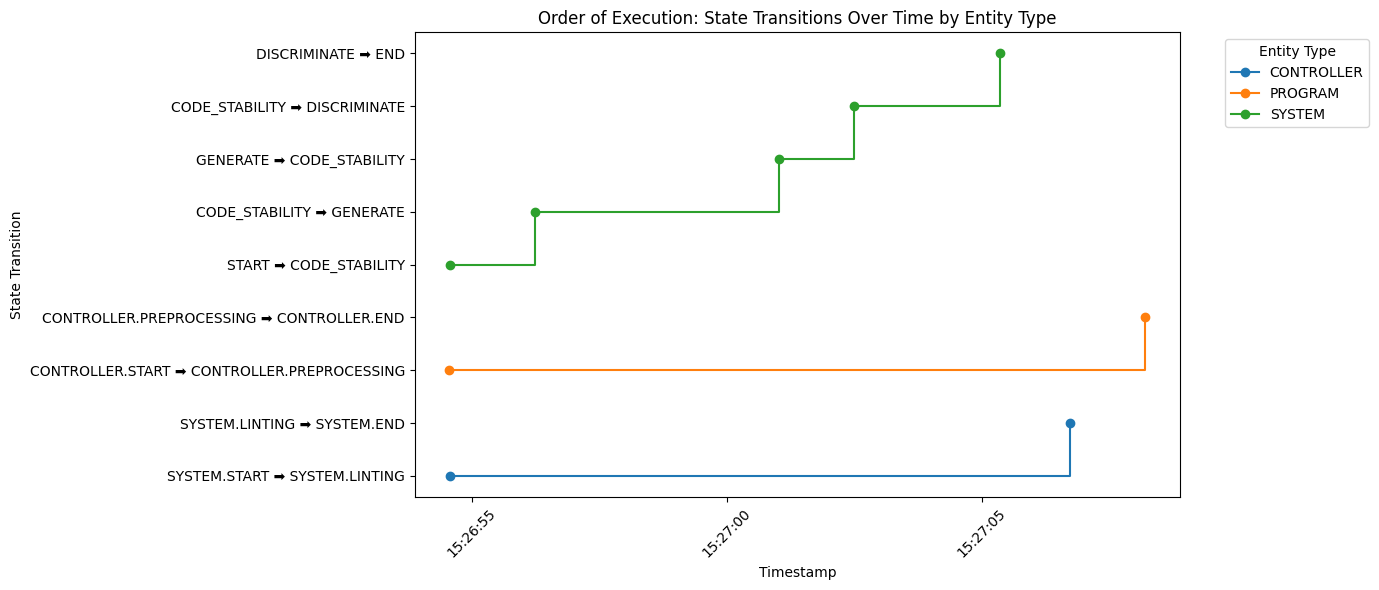

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make a copy of df to ensure we don't modify the original dataframe
df_copy = df.copy()

# Fill missing entity_type values with a placeholder (avoids FutureWarning)
df_copy['entity_type'] = df_copy['entity_type'].fillna('Unknown Provider')

# Convert timestamp to datetime for easier manipulation
df_copy['timestamp'] = pd.to_datetime(df_copy['timestamp'])

# Remove the "STATE." prefix for cleaner labels in the plot
df_copy['from_state'] = df_copy['from_state'].str.replace('STATE.', '', regex=False)
df_copy['to_state'] = df_copy['to_state'].str.replace('STATE.', '', regex=False)

# Create a new column combining from_state and to_state for transitions visualization
df_copy['state_transition'] = df_copy['from_state'] + ' ➡️ ' + df_copy['to_state']

# Sort by timestamp to ensure correct transition order
df_copy = df_copy.sort_values(by='timestamp').reset_index(drop=True)

# Strip the "PROVIDER_TYPE." from entity_type for cleaner legend display
df_copy['entity_type'] = df_copy['entity_type'].str.replace('PROVIDER_TYPE.', '', regex=False)

# Create the plot
plt.figure(figsize=(12, 6))

# Use Matplotlib's step function for better discrete visualization
for label, df_entity in df_copy.groupby('entity_type'):
    plt.step(df_entity['timestamp'], df_entity['state_transition'], label=label, marker='o', where='post')

# Customize the plot
plt.title("Order of Execution: State Transitions Over Time by Entity Type")
plt.xlabel("Timestamp")
plt.ylabel("State Transition")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title="Entity Type", bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.show()


In [5]:
df

,id,session_id,timestamp,entity_type,entity_id,from_state,to_state,reason,decision,triggered_by,step,transition_metadata,input_snapshot_id,output_snapshot_id,run_id,called_by_type,called_by_id
0,1,1,2025-06-08 15:26:54.561606+00:00,PROVIDER_TYPE.PROGRAM,1,CONTROLLER.START,CONTROLLER.PREPROCESSING,TRANSITION_REASON_TYPE.INITIALIZATION,STATE_DECISION_TYPE.INITIAL,codecritic_program,1,"{""original_file"": ""tests\\session_linked_execu...",None,None,9b95fd9a-66c0-41d4-affb-36de9e301572,PROVIDER_TYPE.SESSION,1
1,2,1,2025-06-08 15:26:54.572613+00:00,PROVIDER_TYPE.CONTROLLER,1,SYSTEM.START,SYSTEM.LINTING,TRANSITION_REASON_TYPE.INITIALIZATION,STATE_DECISION_TYPE.INITIAL,preprocessing_controller,2,"{""original_file"": ""working_files\\session_link...",None,None,073b07d6-b22f-4ec8-aa45-13befd6ccff9,PROVIDER_TYPE.PROGRAM,1
2,3,1,2025-06-08 15:26:54.576931+00:00,PROVIDER_TYPE.SYSTEM,1,STATE.START,STATE.CODE_STABILITY,TRANSITION_REASON_TYPE.EVALUATING,STATE_DECISION_TYPE.INITIAL,linting_system_provider,3,"{""original_file"": ""working_files\\session_link...",None,None,644fdea0-cce8-48f3-a68c-8b9549586eaa,PROVIDER_TYPE.CONTROLLER,1
3,4,1,2025-06-08 15:26:56.230561+00:00,PROVIDER_TYPE.SYSTEM,1,STATE.CODE_STABILITY,STATE.GENERATE,TRANSITION_REASON_TYPE.PASSED,STATE_DECISION_TYPE.IMPROVED,linting_system_provider,4,"{""original_file"": ""working_files\\session_link...",None,None,644fdea0-cce8-48f3-a68c-8b9549586eaa,PROVIDER_TYPE.CONTROLLER,1
4,5,1,2025-06-08 15:27:01.031531+00:00,PROVIDER_TYPE.SYSTEM,1,STATE.GENERATE,STATE.CODE_STABILITY,TRANSITION_REASON_TYPE.EVALUATING,STATE_DECISION_TYPE.INITIAL,linting_system_provider,5,"{""original_file"": ""working_files\\session_link...",None,None,644fdea0-cce8-48f3-a68c-8b9549586eaa,PROVIDER_TYPE.CONTROLLER,1
5,6,1,2025-06-08 15:27:02.499621+00:00,PROVIDER_TYPE.SYSTEM,1,STATE.CODE_STABILITY,STATE.DISCRIMINATE,TRANSITION_REASON_TYPE.PASSED,STATE_DECISION_TYPE.IMPROVED,linting_system_provider,6,"{""original_file"": ""working_files\\session_link...",None,None,644fdea0-cce8-48f3-a68c-8b9549586eaa,PROVIDER_TYPE.CONTROLLER,1
6,7,1,2025-06-08 15:27:05.355325+00:00,PROVIDER_TYPE.SYSTEM,1,STATE.DISCRIMINATE,STATE.END,TRANSITION_REASON_TYPE.PASSED,STATE_DECISION_TYPE.FINAL,linting_system_provider,7,"{""original_file"": ""working_files\\session_link...",None,None,644fdea0-cce8-48f3-a68c-8b9549586eaa,PROVIDER_TYPE.CONTROLLER,1
7,8,1,2025-06-08 15:27:06.742787+00:00,PROVIDER_TYPE.CONTROLLER,1,SYSTEM.LINTING,SYSTEM.END,TRANSITION_REASON_TYPE.SUCCESSFUL,STATE_DECISION_TYPE.FINAL,preprocessing_controller,3,"{""original_file"": ""working_files\\session_link...",None,None,073b07d6-b22f-4ec8-aa45-13befd6ccff9,PROVIDER_TYPE.PROGRAM,1
8,9,1,2025-06-08 15:27:08.211725+00:00,PROVIDER_TYPE.PROGRAM,1,CONTROLLER.PREPROCESSING,CONTROLLER.END,TRANSITION_REASON_TYPE.SUCCESSFUL,STATE_DECISION_TYPE.FINAL,codecritic_program,2,"{""original_file"": ""tests\\session_linked_execu...",None,None,9b95fd9a-66c0-41d4-affb-36de9e301572,PROVIDER_TYPE.SESSION,1


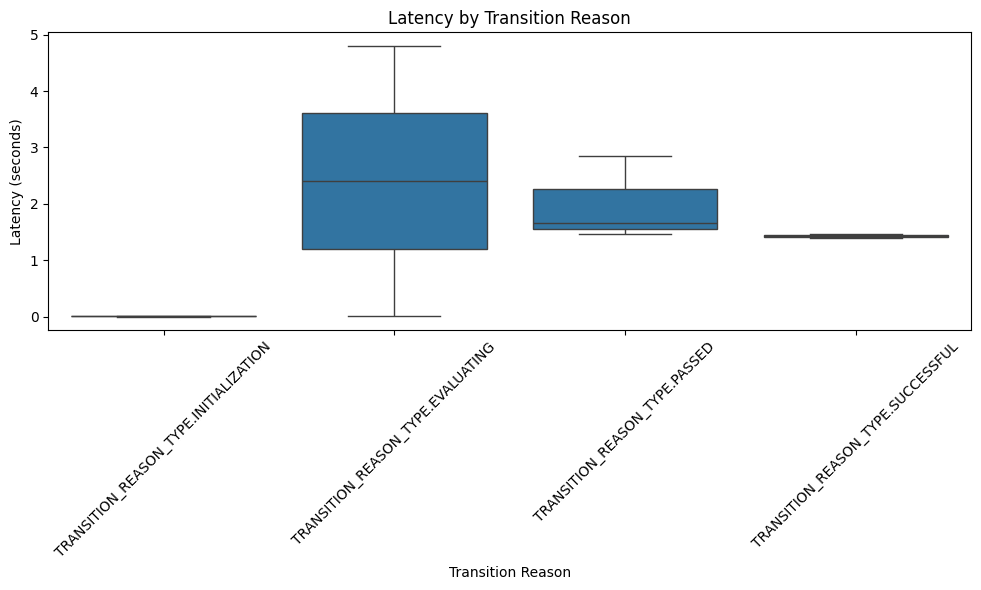

In [6]:
# Latency analysis
df['timestamp_diff'] = df['timestamp'].diff().fillna(pd.Timedelta(0))
df['latency'] = df['timestamp_diff'].dt.total_seconds()

# Latency vs Transition Reason
plt.figure(figsize=(10, 6))
sns.boxplot(x='reason', y='latency', data=df)
plt.title("Latency by Transition Reason")
plt.xlabel('Transition Reason')
plt.ylabel('Latency (seconds)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



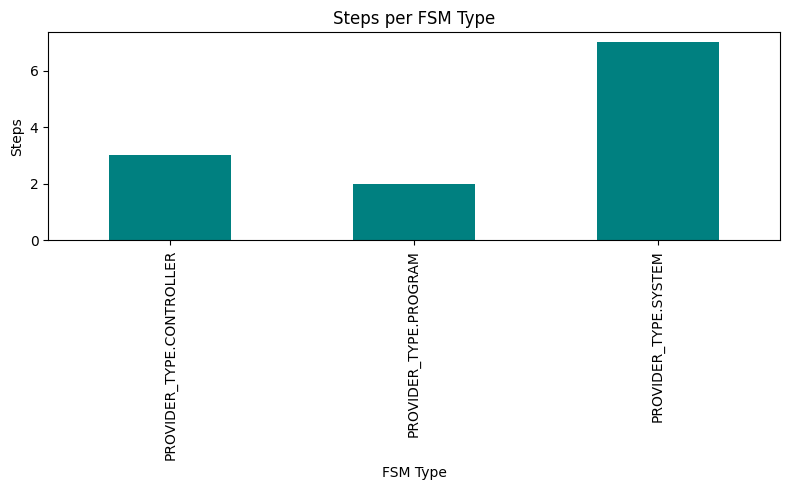

In [7]:
# Steps per FSM Type
steps_per_fsm_type = df.groupby('entity_type')['step'].max()

plt.figure(figsize=(8, 5))
steps_per_fsm_type.plot(kind='bar', color='teal')
plt.title('Steps per FSM Type')
plt.ylabel('Steps')
plt.xlabel('FSM Type')
plt.tight_layout()
plt.show()



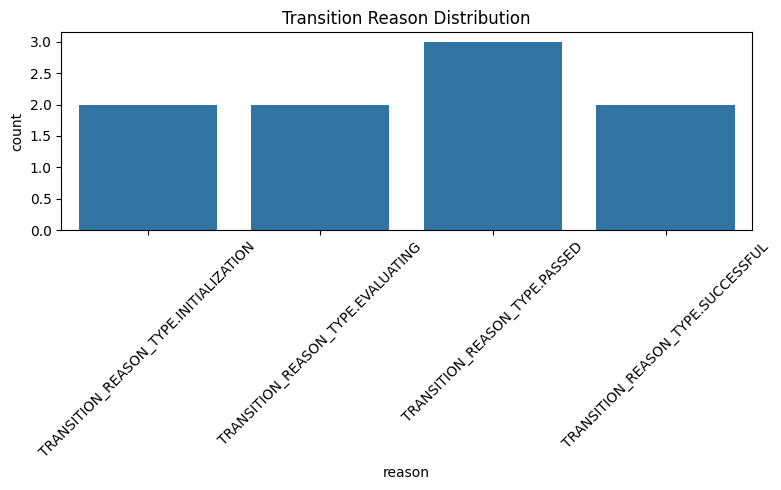

In [8]:
# Transition Reason Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='reason', data=df)
plt.title("Transition Reason Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

